In [2]:
import qiskit
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import math
import numpy as np
from qiskit.circuit.library import HGate
from qiskit.circuit.library import TGate
from qiskit.circuit.library import SGate
from qiskit.circuit.library import SwapGate
from os import error
from qiskit import transpile
from qiskit.visualization import plot_distribution

In [3]:
def QRC(qc):
  gate_control = qc.qregs[0]
  target = qc.qregs[2]

  global x_gate_qrc
  global ccc_h_qrc
  global ccc_t_qrc
  global ccc_s_qrc
  global cccc_not_qrc

  #00
  qc.mcx([gate_control[0],gate_control[1],gate_control[2],target[0]],target[1])

  qc.x(2)

  #01
  t3h_gate = TGate().control(3)
  qc.append(t3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)

  #11
  c3h_gate = HGate().control(3)
  qc.append(c3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(2)

  #10
  s3h_gate = SGate().control(3)
  qc.append(s3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)

  #00

  x_gate_qrc = x_gate_qrc + 4
  ccc_h_qrc = ccc_h_qrc + 1
  ccc_t_qrc = ccc_t_qrc + 1
  ccc_s_qrc = ccc_s_qrc + 1
  cccc_not_qrc = cccc_not_qrc + 1

  qc.barrier()

In [4]:
def Gray_Code_List(n):
    result = []
    for i in range(2 ** n):
        gray = i ^ (i >> 1)
        result.append(format(gray, f'0{n}b'))
    result.append(result[0])
    return result

In [5]:
def Swap_Gate(qc):
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  global x_gate_qrc
  global cc_swap_on_n_qubits_qrc
  global gray_code

  for j in range(len(gray_code)):
    for k in range(len(gray_code[j])):
      if(j == 0):
        break
      if(gray_code[j][k] != gray_code[j-1][k]):
        qc.x(swap_control[k + 1])
        x_gate_qrc = x_gate_qrc + 1

    if(j >= n - 1):
      continue

    controls = [swap_control[k] for k in range(len(swap_control)) if k < 1 + math.ceil(math.log2(n - 1))]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j + 1]])
    cc_swap_on_n_qubits_qrc = cc_swap_on_n_qubits_qrc + 1

  qc.barrier()

In [6]:
def Swap_Gate_CNOT(qc):
  swap_control = qc.qregs[1]
  gate_control = qc.qregs[0]
  target = qc.qregs[2]
  n = len(target)

  global x_gate_qrc
  global cc_swap_on_n_qubits_qrc
  global gray_code

  for j in range(len(gray_code)):
    for k in range(len(gray_code[j])):
      if(j == 0):
        break
      if(gray_code[j][k] != gray_code[j-1][k]):
        qc.x(swap_control[k + 1 + 1 + math.ceil(math.log2(n - 1))])
        x_gate_qrc = x_gate_qrc + 1

    if(j >= n - 1):
      continue

    controls = [swap_control[k] for k in range(len(swap_control)) if k >= 1 + math.ceil(math.log2(n - 1))]
    mc_swap = SwapGate().control(len(controls))
    if(j == 0):
      qc.append(mc_swap, controls + [target[1], target[0]])
    else:
      qc.append(mc_swap, controls + [target[1], target[j + 1]])
    cc_swap_on_n_qubits_qrc = cc_swap_on_n_qubits_qrc + 1

  qc.barrier()

In [7]:
def Reverse_Swap_Gate(qc):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  global x_gate_qrc
  global cc_swap_on_n1_qubits_qrc

  for j in range(len(gray_code)):
    for k in range(len(gray_code[j])):
      if(j == 0):
        break
      if(gray_code[j][k] != gray_code[j-1][k]):
        qc.x(swap_control[k + 1])
        x_gate_qrc = x_gate_qrc + 1

    if(j >= n - 1):
      continue

    controls = [swap_control[k] for k in range(len(swap_control)) if k < 1 + math.ceil(math.log2(n - 1))] + [gate_control[0]]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j + 1]])
    cc_swap_on_n1_qubits_qrc = cc_swap_on_n1_qubits_qrc + 1

  qc.barrier()

In [8]:
def Reverse_Swap_Gate_CNOT(qc):
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  global x_gate_qrc
  global cc_swap_on_n_qubits_qrc

  for j in range(len(gray_code)):
    for k in range(len(gray_code[j])):
      if(j == 0):
        break
      if(gray_code[j][k] != gray_code[j-1][k]):
        qc.x(swap_control[k + 1 + 1 + math.ceil(math.log2(n - 1))])
        x_gate_qrc = x_gate_qrc + 1

    if(j >= n - 1):
      continue

    controls = [swap_control[k] for k in range(len(swap_control)) if k >= 1 + math.ceil(math.log2(n - 1))]
    mc_swap = SwapGate().control(len(controls))
    if(j == 0):
      qc.append(mc_swap, controls + [target[1], target[0]])
    else:
      qc.append(mc_swap, controls + [target[1], target[j + 1]])
    cc_swap_on_n_qubits_qrc = cc_swap_on_n_qubits_qrc + 1

  qc.barrier()

In [9]:
def Print_Target_State(qc, label=""):
    sv = Statevector.from_instruction(qc)
    num_qubits = qc.num_qubits

    target_reg = qc.qregs[2]
    control_reg = qc.qregs[1]

    target_indices = [qc.find_bit(q).index for q in target_reg]
    control_indices = [qc.find_bit(q).index for q in control_reg]

    print("\n==============================")
    print(f"STATE AFTER: {label}")
    print("==============================")

    # ==========================
    # CONTROL REGISTER
    # ==========================
    print("\n--- CONTROL REGISTER ---")

    control_states = {}

    for i, amp in enumerate(sv.data):
        if abs(amp) < 1e-6:
            continue

        bin_state = format(i, f'0{num_qubits}b')

        control_bits = ''.join(
            [bin_state[num_qubits - 1 - idx] for idx in control_indices]
        )

        if control_bits not in control_states:
            control_states[control_bits] = 0

        control_states[control_bits] += amp

    for state, amp in control_states.items():
        magnitude = np.abs(amp)
        phase = np.angle(amp)

        print(f"|{state}>  amplitude = {amp:.4f}  "
              f"|amp|={magnitude:.4f}  phase={phase:.4f}")

    # ==========================
    # TARGET REGISTER
    # ==========================
    print("\n--- TARGET REGISTER ---")

    target_states = {}

    for i, amp in enumerate(sv.data):
        if abs(amp) < 1e-6:
            continue

        bin_state = format(i, f'0{num_qubits}b')

        target_bits = ''.join(
            [bin_state[num_qubits - 1 - idx] for idx in target_indices]
        )

        if target_bits not in target_states:
            target_states[target_bits] = 0

        target_states[target_bits] += amp

    for state, amp in target_states.items():
        magnitude = np.abs(amp)
        phase = np.angle(amp)

        print(f"|{state}>  amplitude = {amp:.4f}  "
              f"|amp|={magnitude:.4f}  phase={phase:.4f}")

    print("\n==============================\n")

In [10]:
def Apply_Gate(qc):
  Swap_Gate(qc)
  Swap_Gate_CNOT(qc)
  QRC(qc)
  Reverse_Swap_Gate_CNOT(qc)
  Reverse_Swap_Gate(qc)

  global reconfigurable_cell_count
  reconfigurable_cell_count = reconfigurable_cell_count + 1

In [11]:
def Apply_Gate_DEBUG(qc):
  Print_Target_State(qc, "Before the CNOT gate")
  Swap_Gate(qc)
  Print_Target_State(qc, "After SWAP")
  Swap_Gate_CNOT(qc)
  Print_Target_State(qc, "After SWAP_CNOT")
  QRC(qc)
  Print_Target_State(qc, "After QRC")
  Reverse_Swap_Gate_CNOT(qc)
  Print_Target_State(qc, "After Reverse_SWAP_CNOT")
  Reverse_Swap_Gate(qc)
  Print_Target_State(qc, "After Reverse_SWAP")

  global reconfigurable_cell_count
  reconfigurable_cell_count = reconfigurable_cell_count + 1

['00', '01', '11', '10', '00']
qubits = 13
x_gate_qrc = 20
c_swap_qrc = 0
cc_swap_on_n_qubits_qrc = 12
cc_swap_on_n1_qubits_qrc = 4
ccc_h_qrc = 1
ccc_t_qrc = 1
ccc_s_qrc = 1
cccc_not_qrc = 1
reconfigurable_cell_count = 1


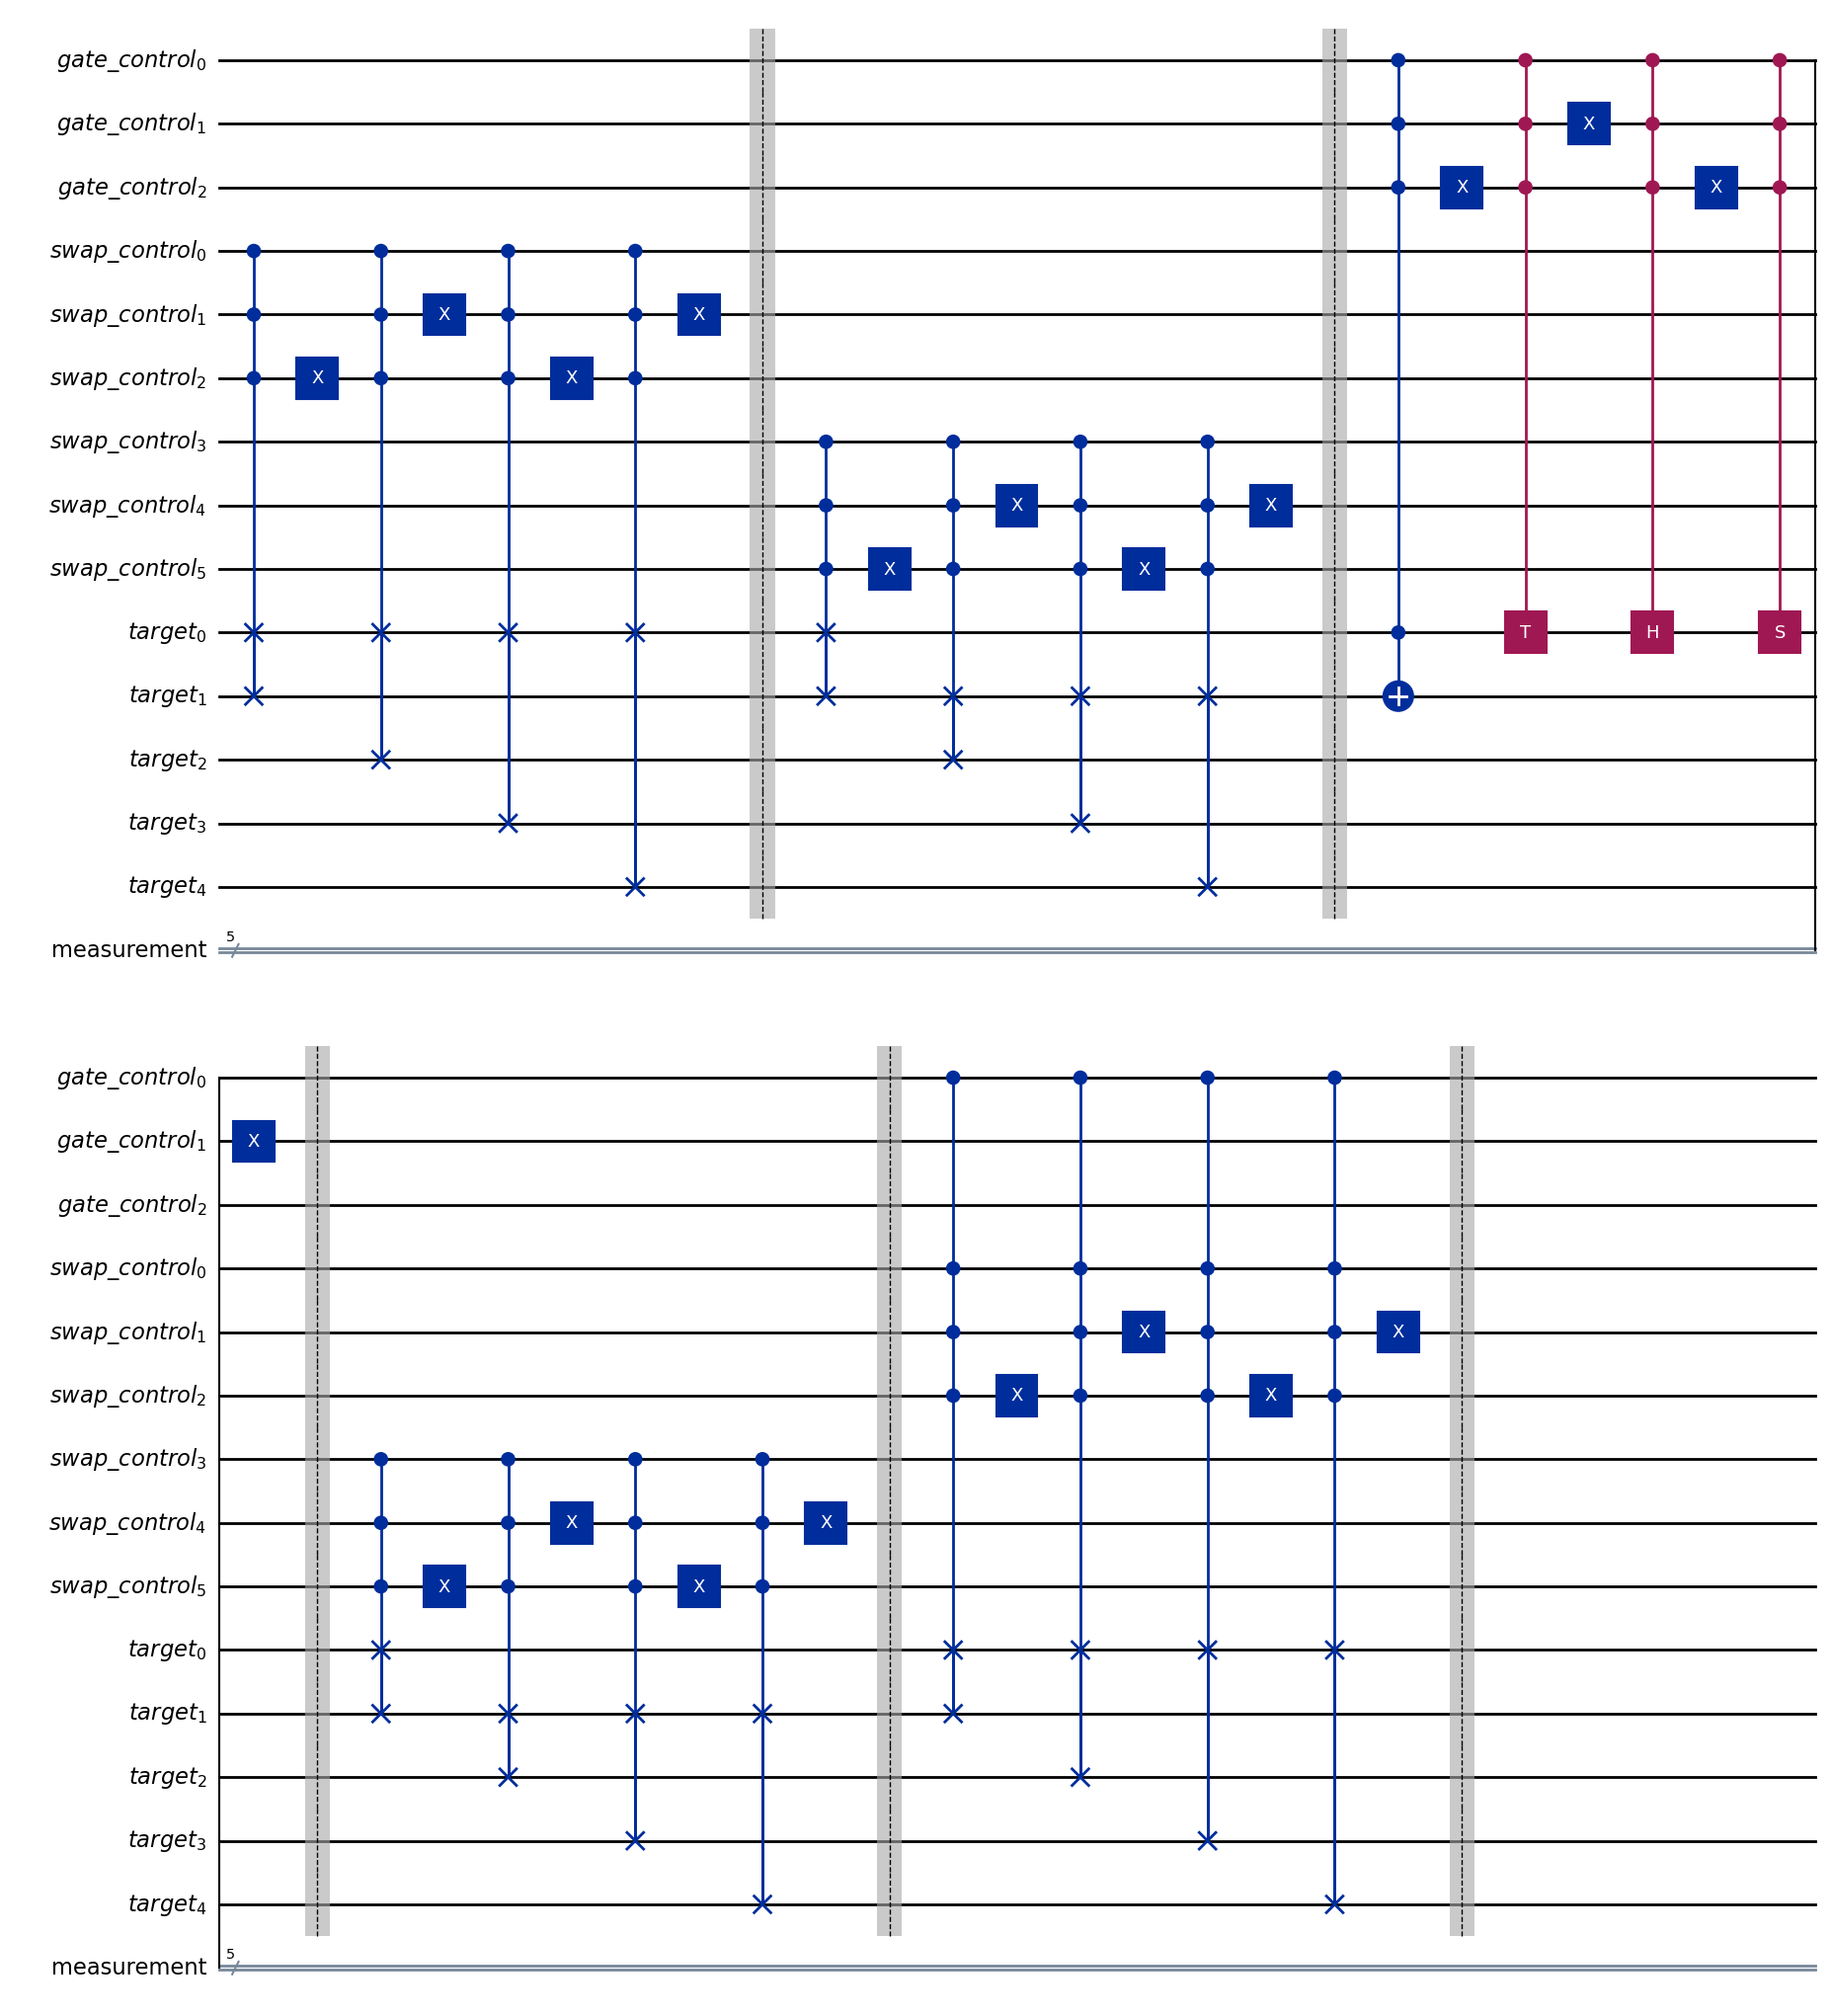

In [12]:
n = 5

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(1 + math.ceil(math.log2(n - 1)) + 1 + math.ceil(math.log2(n - 1)), "swap_control")
target = QuantumRegister(n, "target")

measurement = ClassicalRegister(n, "measurement")

x_gate_qrc = 0
c_swap_qrc = 0
cc_swap_on_n_qubits_qrc = 0
cc_swap_on_n1_qubits_qrc = 0
ccc_h_qrc = 0
ccc_t_qrc = 0
ccc_s_qrc = 0
cccc_not_qrc = 0
reconfigurable_cell_count = 0

gray_code = Gray_Code_List(math.ceil(math.log2(n - 1)))

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

Apply_Gate(qc)

print(gray_code)

print("qubits = " + str(3 + 3 + math.ceil(math.log2(n - 1) + n)))
print("x_gate_qrc = " + str(x_gate_qrc))
print("c_swap_qrc = " + str(c_swap_qrc))
print("cc_swap_on_n_qubits_qrc = " + str(cc_swap_on_n_qubits_qrc))
print("cc_swap_on_n1_qubits_qrc = " + str(cc_swap_on_n1_qubits_qrc))
print("ccc_h_qrc = " + str(ccc_h_qrc))
print("ccc_t_qrc = " + str(ccc_t_qrc))
print("ccc_s_qrc = " + str(ccc_s_qrc))
print("cccc_not_qrc = " + str(cccc_not_qrc))
print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

qc.draw(output="mpl")

In [13]:
def Hardcoded_Apply_Gate_DEBUG(qc, target):
  Print_Target_State(qc, "Before the CNOT gate")
  qc.swap(target[0], target[4])
  Print_Target_State(qc, "After SWAP")
  qc.swap(target[1], target[4])
  Print_Target_State(qc, "After SWAP_CNOT")
  QRC(qc)
  Print_Target_State(qc, "After QRC")
  qc.swap(target[1], target[4])
  Print_Target_State(qc, "After Reverse_SWAP_CNOT")
  qc.swap(target[0], target[4])
  Print_Target_State(qc, "After Reverse_SWAP")

  global reconfigurable_cell_count
  reconfigurable_cell_count = reconfigurable_cell_count + 1

In [14]:
def Modify_Swap_Control_Bits(qc, target_qubit):
  swap_control = qc.qregs[1]

  global x_gate_qrc
  global gray_code

  if(target_qubit == 0):
    qc.x(swap_control[0])
    x_gate_qrc = x_gate_qrc + 1
    return

  binary = gray_code[target_qubit-1]

  bit_id = 0

  for bit in binary:
    bit_id = bit_id + 1
    if bit == '0':
      qc.x(swap_control[bit_id])
      x_gate_qrc = x_gate_qrc + 1

In [15]:
def Modify_Swap_Control_Bits_CNOT(qc, target_qubit):
  swap_control = qc.qregs[1]

  global x_gate_qrc
  global gray_code

  if(target_qubit == 1):
    qc.x(swap_control[int(len(swap_control)/2)])
    x_gate_qrc = x_gate_qrc + 1
    return

  if(target_qubit == 0):
    target_qubit = 1

  binary = gray_code[target_qubit-1]

  bit_id = int(len(swap_control)/2)

  for bit in binary:
    bit_id = bit_id + 1
    if bit == '0':
      qc.x(swap_control[bit_id])
      x_gate_qrc = x_gate_qrc + 1

In [16]:
def NOP_Gate(qc, target_qubit):
  gate_control = qc.qregs[0]

  global x_gate_qrc

  #Apply X on gate qubits
  qc.x(gate_control[0])
  x_gate_qrc = x_gate_qrc + 1

  #Apply X on swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()
  #qc.x(swap_control[target_qubit])

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()
  #qc.x(swap_control[target_qubit])

  #Restore gate qubits
  qc.x(gate_control[0])
  x_gate_qrc = x_gate_qrc + 1

In [17]:
def H_Gate(qc, target_qubit):
  #Apply X on gate qubits
  #Nothing to do for H Gate

  #Apply X on swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Restore gate qubits
  #Nothing to do for H Gate

In [18]:
def T_Gate(qc, target_qubit):
  gate_control = qc.qregs[0]

  global x_gate_qrc
  
  #Apply X on gate qubits
  qc.x(gate_control[1])
  x_gate_qrc = x_gate_qrc + 1

  #Apply X on swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Restore gate qubits
  qc.x(gate_control[1])
  x_gate_qrc = x_gate_qrc + 1

In [19]:
def S_Gate(qc, target_qubit):
  gate_control = qc.qregs[0]

  global x_gate_qrc

  #Apply X on gate qubits
  qc.x(gate_control[2])
  x_gate_qrc = x_gate_qrc + 1

  #Apply X on swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Restore gate qubits
  qc.x(gate_control[2])
  x_gate_qrc = x_gate_qrc + 1

In [20]:
def CNOT_Gate(qc, control_qubit, target_qubit):
  #== CORRECT ONE==
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]
  
  global x_gate_qrc

  if(control_qubit == target_qubit):
    raise ValueError(f"Error: Control and target qubits of the CNOT gate must be different!")

  #if we want to apply CNOT with target on the second position, we don't have to make the NOP to move the target,
  #due to it already being in the correct position
  if(target_qubit != 1):
    #if the control qubit is on the first position, than after the swaps made on the target qubit it will be left
    #in the place of the target qubit and we need to adjust the value of the control qubit to know which qubit
    #needs to be swapped back to the first position
    if(control_qubit == 0):
      control_qubit = target_qubit

    #if the control qubit is on the second position, than after the swaps made on the target qubit it will be left
    #on the first position and we need to adjust the value of the control qubit to know which qubit needs to be
    #swapped back to the first position
    if(control_qubit == 1):
      control_qubit = 0

    #Apply NOP to move target qubit to the first position
    NOP_Gate(qc, target_qubit)

    #Apply NOP to move target to the second position
    NOP_Gate(qc, 1)

  #Apply CNOT gate
  #Apply X on gate qubits
  qc.x(gate_control[1])
  qc.x(gate_control[2])
  x_gate_qrc = x_gate_qrc + 2

  #Apply X on swap qubits
  #qc.x(swap_control[control_qubit])
  Modify_Swap_Control_Bits(qc, control_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  #qc.x(swap_control[control_qubit])
  Modify_Swap_Control_Bits(qc, control_qubit)
  qc.barrier()

  #Restore gate qubits
  qc.x(gate_control[1])
  qc.x(gate_control[2])
  x_gate_qrc = x_gate_qrc + 2

  if(target_qubit != 1):
    #Apply NOP to move target back to the first position
    NOP_Gate(qc, 1)

    #Apply NOP to move target back to the original position
    NOP_Gate(qc, target_qubit)

In [21]:
def CNOT_Gate(qc, control_qubit, target_qubit):
  #== WRONG ONE==

  qubits_positions = [0, 1, 2 , 3, 4]

  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]
  target = qc.qregs[2]

  if(control_qubit == target_qubit):
    raise ValueError(f"Error: Control and target qubits of the CNOT gate must be different!")


  if (target_qubit == 0):
    target_qubit = control_qubit

  qc.x(gate_control[1])
  qc.x(gate_control[2])

  qc.x(swap_control[1 + math.ceil(math.log2(len(target) - 1))])

  #print(qubits_positions)

  #Print_Target_State(qc, "")

  Modify_Swap_Control_Bits(qc, control_qubit)
  #aux = qubits_positions[0]
  #qubits_positions[0] = qubits_positions[control_qubit]
  #qubits_positions[control_qubit] = aux
  #print(qubits_positions)

  Modify_Swap_Control_Bits_CNOT(qc, target_qubit)
  #aux = qubits_positions[1]
  #qubits_positions[1] = qubits_positions[target_qubit]
  #qubits_positions[target_qubit] = aux
  #print(qubits_positions)

  qc.barrier()

  Apply_Gate(qc)
  #Apply_Gate_DEBUG(qc)

  Modify_Swap_Control_Bits(qc, control_qubit)
  #aux = qubits_positions[1]
  #qubits_positions[1] = qubits_positions[target_qubit]
  #qubits_positions[target_qubit] = aux
  #print(qubits_positions)

  Modify_Swap_Control_Bits_CNOT(qc, target_qubit)
  #aux = qubits_positions[0]
  #qubits_positions[0] = qubits_positions[control_qubit]
  #qubits_positions[control_qubit] = aux
  #print(qubits_positions)

  qc.x(gate_control[1])
  qc.x(gate_control[2])
  qc.x(swap_control[1 + math.ceil(math.log2(len(target) - 1))])

  global x_gate_qrc
  x_gate_qrc = x_gate_qrc + 6

  qc.barrier()

In [22]:
def Z_Gate(qc, target_qubit):
  S_Gate(qc, target_qubit)
  S_Gate(qc, target_qubit)

In [23]:
def X_Gate(qc, target_qubit):
  H_Gate(qc, target_qubit)
  Z_Gate(qc, target_qubit)
  H_Gate(qc, target_qubit)

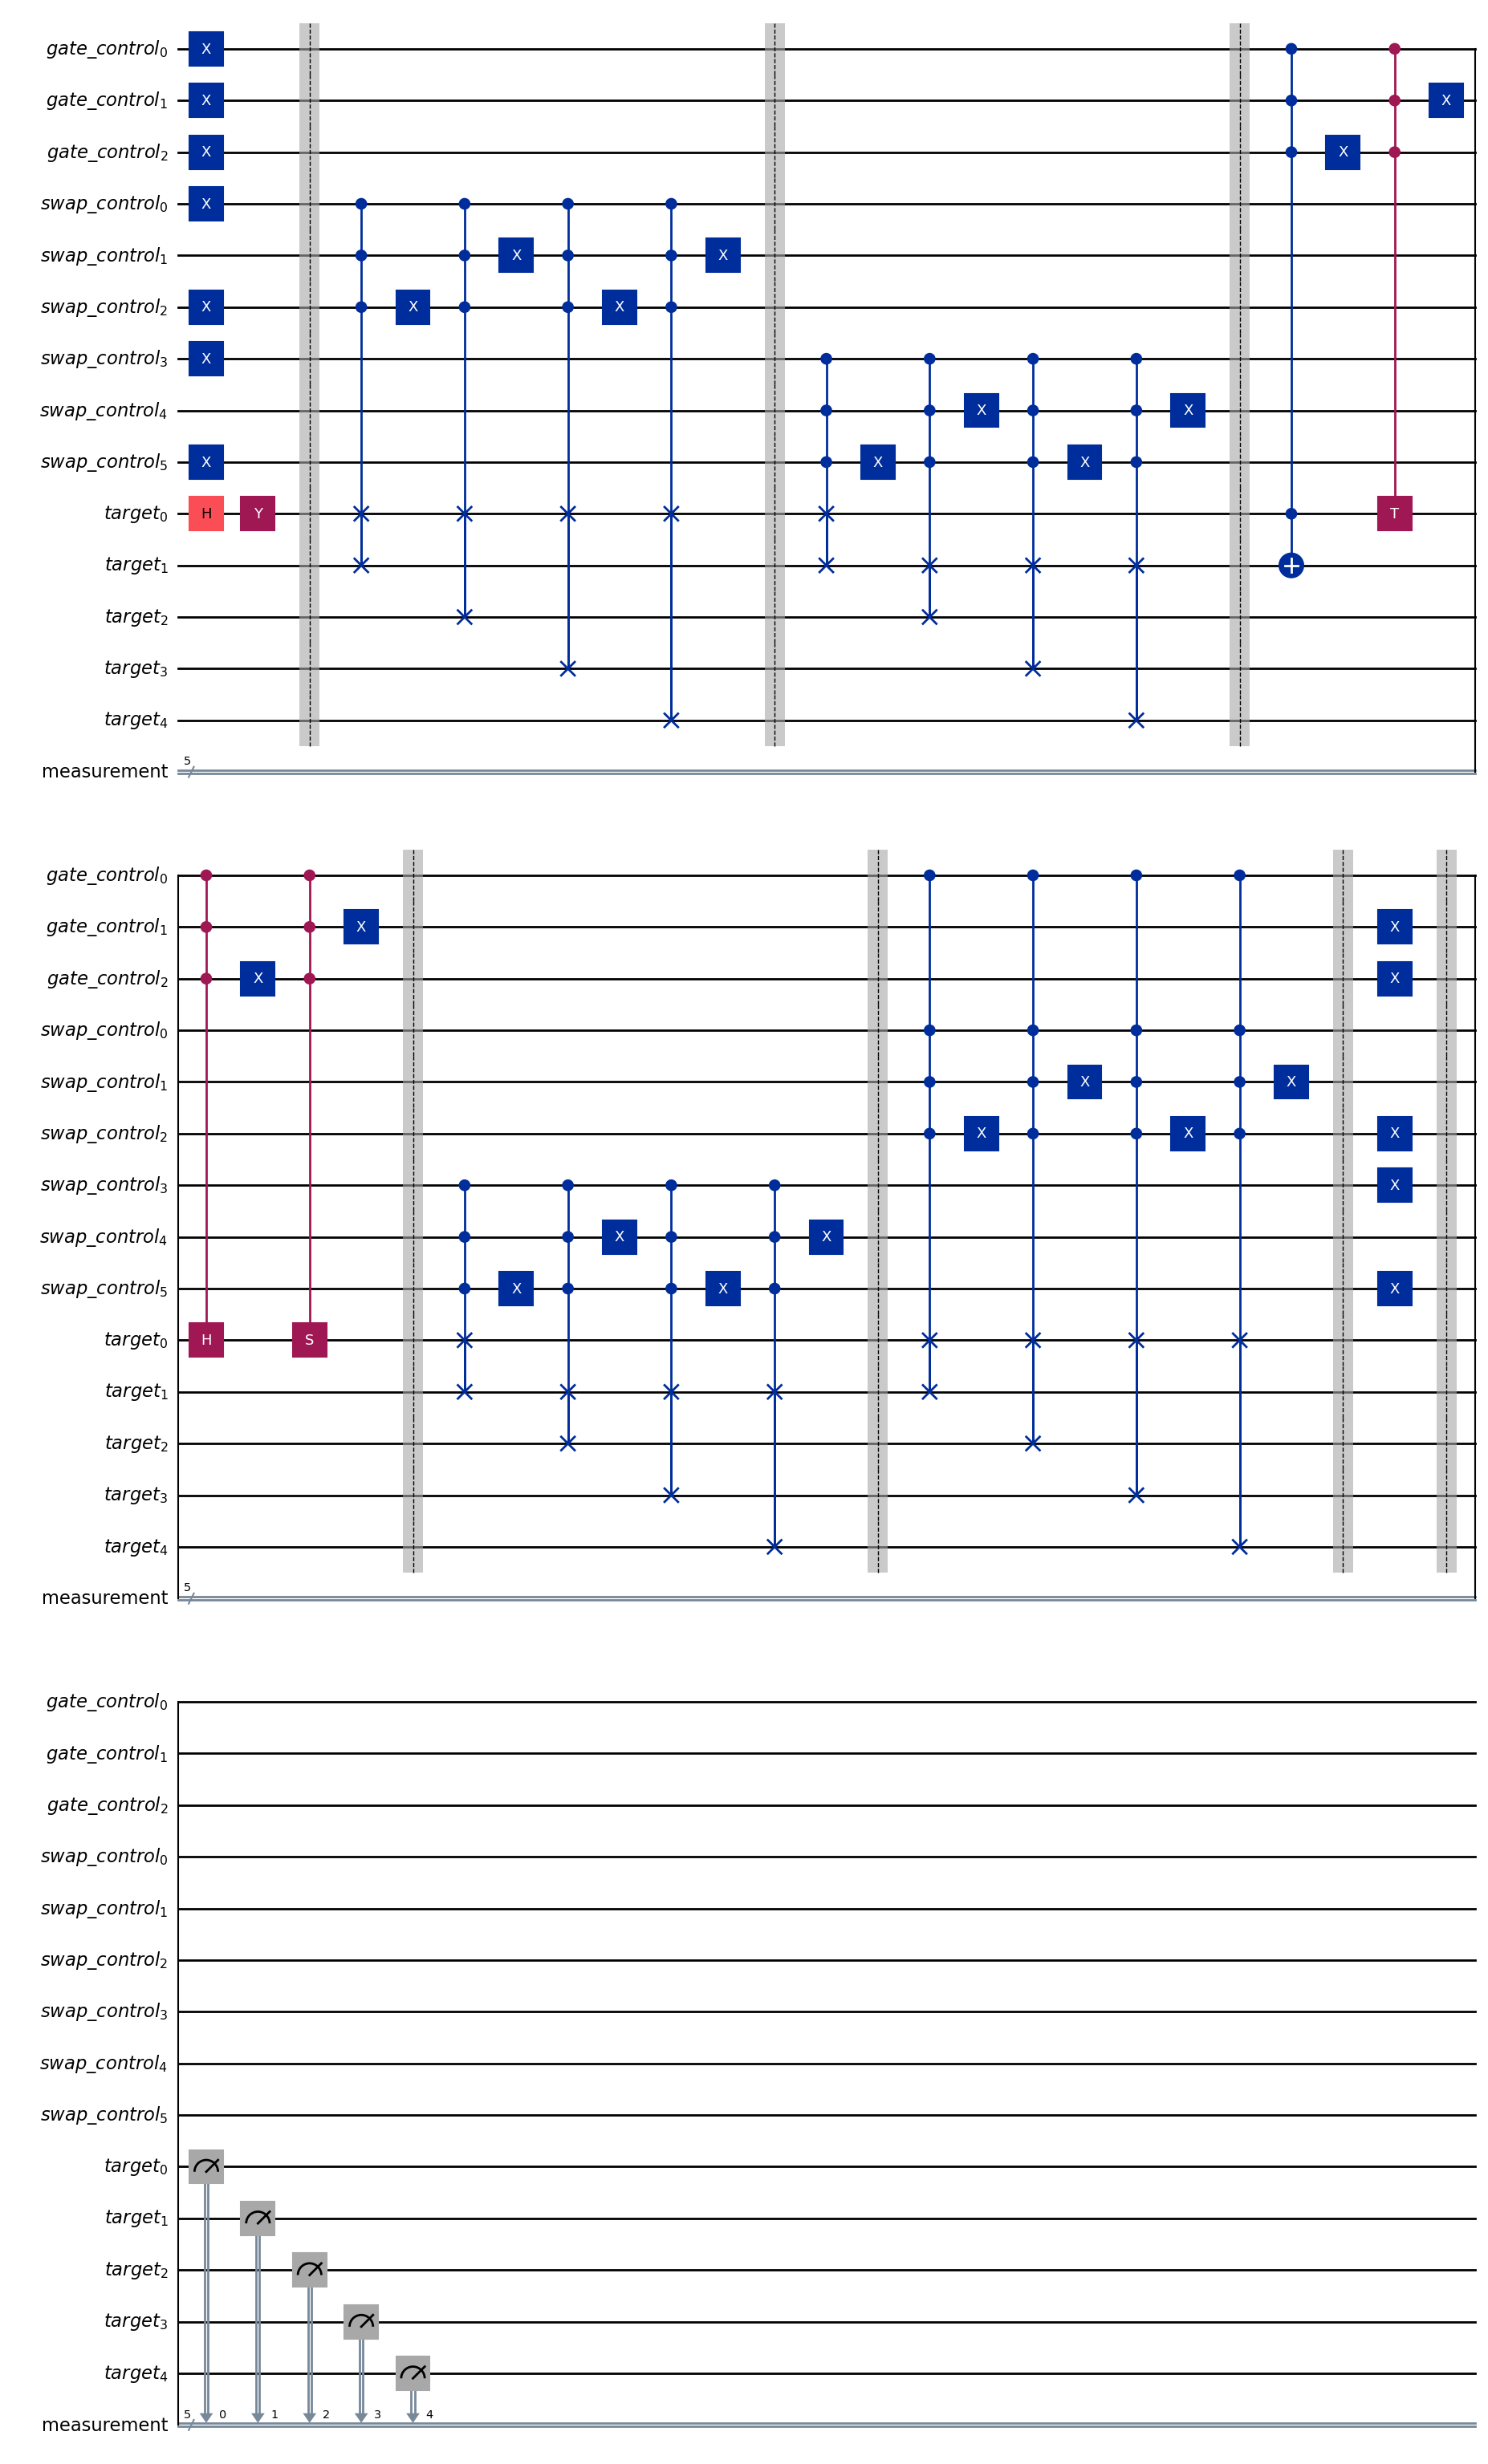

In [24]:
n = 5

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(1 + math.ceil(math.log2(n - 1)) + 1 + math.ceil(math.log2(n - 1)), "swap_control")
target = QuantumRegister(n, "target")

measurement = ClassicalRegister(n, "measurement")

reconfigurable_cell_count = 0

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

qc.x(gate_control[0])
qc.x(swap_control[0])

#H_Gate(qc, 1)
qc.h(target[0])
qc.y(target[0])
CNOT_Gate(qc, 4, 0)
#Toffoli_Gate(qc, 0, 1, 4)

qc.measure(target, range(n))

qc.draw(output="mpl")

{'00000': 4982, '00001': 5018}


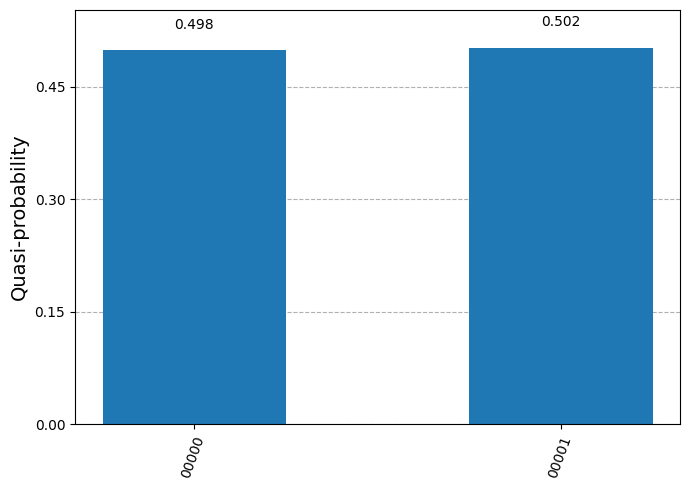

In [25]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
qc.measure(target, measurement)

qc_t = transpile(qc, sim, optimization_level=3)
result = sim.run(qc_t, shots=10_000).result()

counts = result.get_counts()
print(counts)

plot_distribution(counts)

In [26]:
def T_Dagger_Gate(qc, target_qubit):
  Z_Gate(qc, target_qubit)
  S_Gate(qc, target_qubit)
  T_Gate(qc, target_qubit)

In [27]:
def Toffoli_Gate(qc, control_qubit_1, control_qubit_2, target_qubit):
  T_Dagger_Gate(qc, control_qubit_1)
  #Print_Target_State(qc, "")
  T_Dagger_Gate(qc, control_qubit_2)
  #Print_Target_State(qc, "")
  H_Gate(qc, target_qubit)
  #Print_Target_State(qc, "")

  CNOT_Gate(qc, target_qubit, control_qubit_1)
  #Print_Target_State(qc, "")

  T_Gate(qc, control_qubit_1)
  #Print_Target_State(qc, "")
  CNOT_Gate(qc, control_qubit_2, target_qubit)
  #Print_Target_State(qc, "")

  CNOT_Gate(qc, control_qubit_2, control_qubit_1)
  #Print_Target_State(qc, "")
  T_Gate(qc, target_qubit)
  #Print_Target_State(qc, "")

  T_Dagger_Gate(qc, control_qubit_1)
  #Print_Target_State(qc, "")
  CNOT_Gate(qc, control_qubit_2, target_qubit)
  #Print_Target_State(qc, "")

  CNOT_Gate(qc, target_qubit, control_qubit_1)
  #Print_Target_State(qc, "")

  T_Gate(qc, control_qubit_1)
  #Print_Target_State(qc, "")
  T_Dagger_Gate(qc, target_qubit)
  #Print_Target_State(qc, "")

  CNOT_Gate(qc, control_qubit_2, control_qubit_1)
  #Print_Target_State(qc, "")
  H_Gate(qc, target_qubit)
  #Print_Target_State(qc, "")

In [28]:
def Toffoli_Gate_3(qc, control_qubits, target_qubit, ancilla_qubit):
  Toffoli_Gate(qc, control_qubits[0], control_qubits[1], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[0], control_qubits[1], ancilla_qubit)

In [29]:
def Toffoli_Gate_4(qc, control_qubits, target_qubit, ancilla_qubit):
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)

    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)

    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], ancilla_qubit)

In [30]:
def Toffoli_Gate_5(qc, control_qubits, target_qubit, ancilla_qubit):
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])

    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

In [31]:
def Toffoli_Gate_6(qc, control_qubits, target_qubit, ancilla_qubit):
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

    Toffoli_Gate(qc, control_qubits[4], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])
    Toffoli_Gate(qc, control_qubits[4], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])

    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

In [32]:
def Toffoli_Gate_7(qc, control_qubits, target_qubit, ancilla_qubit):
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])

  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

In [33]:
def Toffoli_Gate_8(qc, control_qubits, target_qubit, ancilla_qubit):
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[0])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[0])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])

  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

In [34]:
def Reconfigurable_Oracle(qc, target_value):
  for i in range(len(target_value)):
    if(target_value[i] != '1'):
      X_Gate(qc, i)

  match len(target_value):
    case 3:
      Toffoli_Gate_3(qc, [0, 1, 2], 3, 4)
    case 4:
      Toffoli_Gate_4(qc, [0, 1, 2, 3], 4, 5)
    case 5:
      Toffoli_Gate_5(qc, [0, 1, 2, 3, 4], 5, 6)
    case 6:
      Toffoli_Gate_6(qc, [0, 1, 2, 3, 4, 5], 6, 7)
    case 7:
      Toffoli_Gate_7(qc, [0, 1, 2, 3, 4, 5, 6], 7, 8)
    case 8:
      Toffoli_Gate_8(qc, [0, 1, 2, 3, 4, 5, 6, 7], 8, 9)

  for i in range(len(target_value)):
    if(target_value[i] != '1'):
      X_Gate(qc, i)

In [35]:
def Reconfigurable_Diffuser(qc):
  n = len(qc.qregs[2]) - 2

  for i in range(n):
    H_Gate(qc, i)
    X_Gate(qc, i)

  H_Gate(qc, n-1)

  match n:
    case 2:
      CNOT_Gate(qc, 0, 1)
    case 3:
      Toffoli_Gate(qc, 0, 1, 2)
    case 4:
      Toffoli_Gate_3(qc, [0, 1, 2], 3, 5)
    case 5:
      Toffoli_Gate_4(qc, [0, 1, 2, 3], 4, 6)
    case 6:
      Toffoli_Gate_5(qc, [0, 1, 2, 3, 4], 5, 7)
    case 7:
      Toffoli_Gate_6(qc, [0, 1, 2, 3, 4, 5], 6, 8)
    case 8:
      Toffoli_Gate_7(qc, [0, 1, 2, 3, 4, 5, 6], 7, 9)

  H_Gate(qc, n-1)

  for i in range(n):
    X_Gate(qc, i)
    H_Gate(qc, i)

In [ ]:
#target_value = "110"
#target_value = "1101"
#target_value = "11010"
#target_value = "110100"
#target_value = "1101001"
target_value = "11010010"

n = len(target_value)

gate_control = QuantumRegister(3, "gate_control")
#swap_control = QuantumRegister(3 + math.ceil(math.log2(n+1)), "swap_control")
swap_control = QuantumRegister(1 + math.ceil(math.log2(n+1)) + 1 + math.ceil(math.log2(n+1)), "swap_control")
target = QuantumRegister(n+1+1, "target")

measurement = ClassicalRegister(n+1+1, "measurement")

x_gate_qrc = 0
c_swap_qrc = 0
cc_swap_on_n_qubits_qrc = 0
cc_swap_on_n1_qubits_qrc = 0
ccc_h_qrc = 0
ccc_t_qrc = 0
ccc_s_qrc = 0
cccc_not_qrc = 0
reconfigurable_cell_count = 0

gray_code = Gray_Code_List(math.ceil(math.log2(n+1)))

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

reconfigurable_cell_count = 0

qc.x(gate_control[0])
qc.x(swap_control[0])
x_gate_qrc = x_gate_qrc + 2

#Start
X_Gate(qc, n)

for i in range(n+1):
  H_Gate(qc, i)

steps = math.sqrt(math.pow(2,n))
steps = round(math.pi/4 * steps)

print(steps)

for i in range(steps):
  Reconfigurable_Oracle(qc, target_value)
  Reconfigurable_Diffuser(qc)

H_Gate(qc, n)
X_Gate(qc, n)

#End
qc.x(gate_control[0])
qc.x(swap_control[0])
x_gate_qrc = x_gate_qrc + 2

qc.measure(target, range(n+1+1))

print("qubits = " + str(7 + math.ceil(math.log2(n+1)) + math.ceil(math.log2(n+1)) + n))
print("x_gate_qrc = " + str(x_gate_qrc))
print("c_swap_qrc = " + str(c_swap_qrc))
print("cc_swap_on_" + str(1 + math.ceil(math.log2(n+1))) + "_qubits_qrc = " + str(cc_swap_on_n_qubits_qrc))
print("cc_swap_on_" + str(2 + math.ceil(math.log2(n+1))) + "_qubits_qrc = " + str(cc_swap_on_n1_qubits_qrc))
print("ccc_h_qrc = " + str(ccc_h_qrc))
print("ccc_t_qrc = " + str(ccc_t_qrc))
print("ccc_s_qrc = " + str(ccc_s_qrc))
print("cccc_not_qrc = " + str(cccc_not_qrc))
print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

print(gray_code)

#qc.draw("mpl")

13
qubits = 23
x_gate_qrc = 1494096
c_swap_qrc = 0
cc_swap_on_5_qubits_qrc = 533304
cc_swap_on_6_qubits_qrc = 177768
ccc_h_qrc = 19752
ccc_t_qrc = 19752
ccc_s_qrc = 19752
cccc_not_qrc = 19752
reconfigurable_cell_count = 19752
['0000', '0001', '0011', '0010', '0110', '0111', '0101', '0100', '1100', '1101', '1111', '1110', '1010', '1011', '1001', '1000', '0000']


{'0000111100': 2, '0011010010': 2, '0001001011': 9868, '0000001000': 1, '0011111101': 1, '0010111000': 3, '0010011001': 1, '0010101010': 1, '0000011001': 2, '0001100110': 2, '0011001111': 1, '0010101000': 1, '0001111011': 2, '0010111110': 1, '0001010000': 1, '0011011000': 1, '0000111001': 1, '0010100111': 2, '0000001011': 2, '0001110001': 1, '0000100010': 2, '0011010011': 1, '0000111011': 1, '0000100101': 1, '0000001110': 1, '0000100001': 2, '0000011111': 1, '0001100011': 2, '0000111000': 1, '0000000010': 1, '0010000111': 1, '0010110101': 1, '0011100001': 1, '0001000010': 1, '0000000100': 1, '0010010111': 1, '0000001111': 2, '0011110011': 1, '0011010001': 1, '0010001001': 2, '0001100111': 1, '0000010101': 1, '0011100101': 1, '0000110111': 2, '0010011010': 1, '0010110110': 1, '0001011100': 1, '0011101001': 1, '0001000101': 3, '0001010110': 1, '0010111001': 1, '0010000000': 3, '0010111111': 2, '0001010011': 1, '0000101001': 2, '0010011101': 2, '0001111111': 1, '0001000011': 2, '001110001

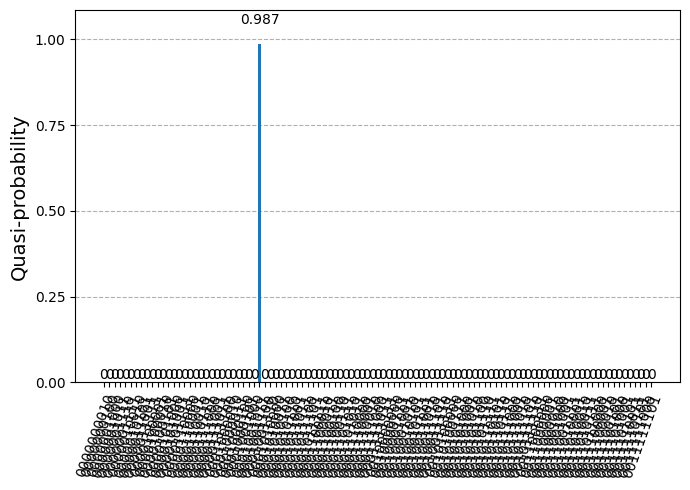

In [37]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
qc.measure(target, measurement)

qc_t = transpile(qc, sim, optimization_level=3)
result = sim.run(qc_t, shots=10_000).result()

counts = result.get_counts()
print(counts)

plot_distribution(counts)